# Advanced Keras Custom Components

This notebook covers **Part 2 (i-ix)** of the assignment on advanced deep learning customization.

**Topics covered:**
- **Custom Learning Rate Scheduler**: Warmup, cosine decay, cyclical LR
- **Custom Loss Function**: Focal loss, contrastive loss, custom weighted loss
- **Custom Activation Function**: Swish variants, parametric activations
- **Custom Layers**: Attention layer, residual block, squeeze-excitation
- **Custom Metrics**: F1 score, precision-recall, custom accuracy
- **Custom Model**: Subclassed model with custom training logic

**Framework:** TensorFlow/Keras

**Dataset:** Fashion MNIST

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.19.0


In [2]:
# Load Fashion MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

X_val, y_val = X_train[:5000], y_train[:5000]
X_train, y_train = X_train[5000:], y_train[5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


---
## Part 1: Custom Learning Rate Schedulers

In [3]:
class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    """Learning rate with linear warmup followed by cosine decay."""

    def __init__(self, initial_lr, warmup_steps, decay_steps):
        super().__init__()
        self.initial_lr = initial_lr
        self.warmup_steps = warmup_steps
        self.decay_steps = decay_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.initial_lr * (step / self.warmup_steps)

        decay_step = step - self.warmup_steps
        cosine_decay = 0.5 * (1 + tf.cos(np.pi * decay_step / self.decay_steps))
        decayed_lr = self.initial_lr * cosine_decay

        return tf.where(step < self.warmup_steps, warmup_lr, decayed_lr)

    def get_config(self):
        return {'initial_lr': self.initial_lr, 'warmup_steps': self.warmup_steps, 'decay_steps': self.decay_steps}

In [4]:
class CyclicalLearningRate(keras.optimizers.schedules.LearningRateSchedule):
    """Cyclical learning rate that oscillates between min and max values."""

    def __init__(self, min_lr, max_lr, step_size):
        super().__init__()
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.step_size = step_size

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        cycle = tf.floor(1 + step / (2 * self.step_size))
        x = tf.abs(step / self.step_size - 2 * cycle + 1)
        return self.min_lr + (self.max_lr - self.min_lr) * tf.maximum(0.0, 1 - x)

    def get_config(self):
        return {'min_lr': self.min_lr, 'max_lr': self.max_lr, 'step_size': self.step_size}

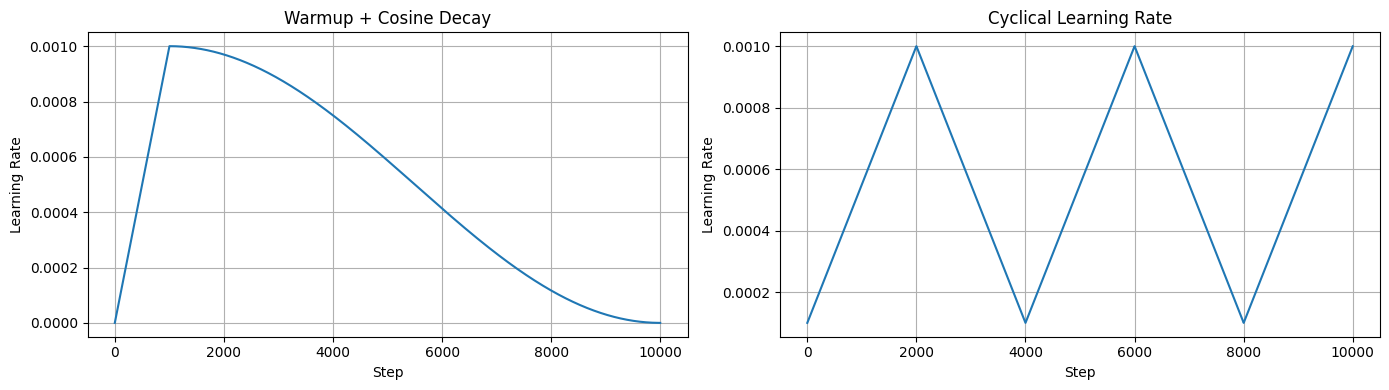

In [5]:
# Visualize learning rate schedules
steps = np.arange(0, 10000)

warmup_cosine = WarmupCosineDecay(initial_lr=0.001, warmup_steps=1000, decay_steps=9000)
cyclical = CyclicalLearningRate(min_lr=0.0001, max_lr=0.001, step_size=2000)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(steps, [warmup_cosine(s).numpy() for s in steps])
axes[0].set_title('Warmup + Cosine Decay')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Learning Rate')
axes[0].grid(True)

axes[1].plot(steps, [cyclical(s).numpy() for s in steps])
axes[1].set_title('Cyclical Learning Rate')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Learning Rate')
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## Part 2: Custom Loss Functions

In [6]:
class FocalLoss(keras.losses.Loss):
    """Focal loss for handling class imbalance - down-weights easy examples."""

    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        weight = self.alpha * y_true_one_hot * tf.pow(1 - y_pred, self.gamma)
        focal_loss = weight * cross_entropy

        return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=-1))

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha})
        return config

In [7]:
class LabelSmoothingLoss(keras.losses.Loss):
    """Cross-entropy with label smoothing for better generalization."""

    def __init__(self, smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.smoothing = smoothing

    def call(self, y_true, y_pred):
        num_classes = tf.shape(y_pred)[-1]
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=num_classes)

        # Apply label smoothing
        y_true_smooth = y_true_one_hot * (1 - self.smoothing) + self.smoothing / tf.cast(num_classes, tf.float32)

        return keras.losses.categorical_crossentropy(y_true_smooth, y_pred)

    def get_config(self):
        config = super().get_config()
        config.update({'smoothing': self.smoothing})
        return config

In [8]:
@keras.utils.register_keras_serializable()
def weighted_categorical_crossentropy(class_weights):
    """Factory function for weighted cross-entropy loss."""
    weights = tf.constant(class_weights, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.squeeze(y_true)
        sample_weights = tf.gather(weights, y_true)
        ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(ce * sample_weights)

    return loss

# Example: weight rare classes higher
class_weights = [1.0, 1.0, 1.5, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0]  # Higher weight for classes 2 and 5

---
## Part 3: Custom Activation Functions

In [9]:
@keras.utils.register_keras_serializable()
def mish(x):
    """Mish activation: x * tanh(softplus(x)). Self-regularizing and smooth."""
    return x * tf.tanh(tf.nn.softplus(x))

@keras.utils.register_keras_serializable()
def swish(x):
    """Swish activation: x * sigmoid(x). Smooth, non-monotonic."""
    return x * tf.sigmoid(x)

@keras.utils.register_keras_serializable()
def gelu(x):
    """Gaussian Error Linear Unit - used in transformers."""
    return 0.5 * x * (1 + tf.tanh(tf.sqrt(2 / np.pi) * (x + 0.044715 * tf.pow(x, 3))))

In [10]:
class ParametricSwish(layers.Layer):
    """Learnable Swish: x * sigmoid(beta * x) where beta is trainable."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.beta = self.add_weight(
            name='beta',
            shape=(1,),
            initializer='ones',
            trainable=True
        )
        super().build(input_shape)

    def call(self, x):
        return x * tf.sigmoid(self.beta * x)

    def get_config(self):
        return super().get_config()

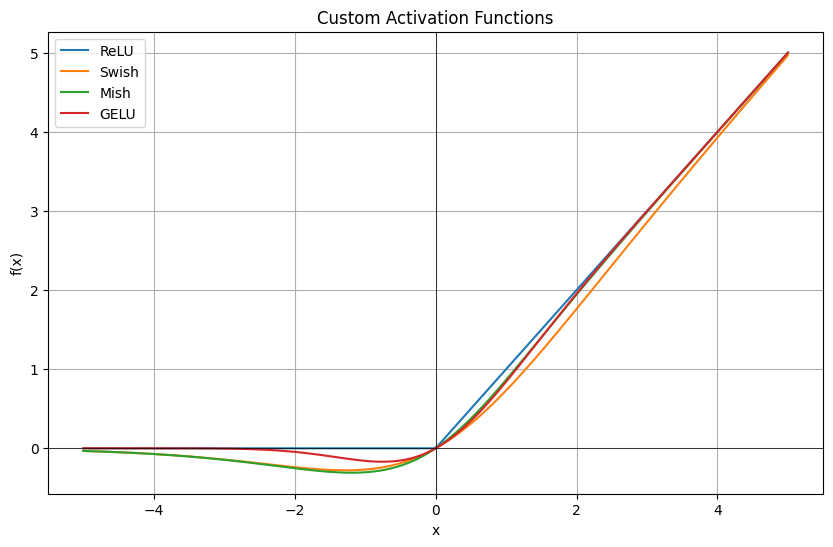

In [12]:
x = np.linspace(-5, 5, 200)

@keras.utils.register_keras_serializable()
def gelu(x):
    """Gaussian Error Linear Unit - used in transformers."""
    # Ensure x is float32
    x = tf.cast(x, tf.float32)
    # Ensure the constant derived from np.pi is also float32
    sqrt_const_two_over_pi = tf.cast(tf.sqrt(2.0 / np.pi), tf.float32)
    return 0.5 * x * (1 + tf.tanh(sqrt_const_two_over_pi * (x + 0.044715 * tf.pow(x, 3))))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, tf.nn.relu(x), label='ReLU')
ax.plot(x, swish(x), label='Swish')
ax.plot(x, mish(x), label='Mish')
ax.plot(x, gelu(x), label='GELU')
ax.set_title('Custom Activation Functions')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend()
ax.grid(True)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
plt.show()

---
## Part 4: Custom Layers

In [13]:
class SelfAttention(layers.Layer):
    """Self-attention layer for capturing global dependencies."""

    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.W_q = self.add_weight('W_q', shape=(input_shape[-1], self.units), initializer='glorot_uniform')
        self.W_k = self.add_weight('W_k', shape=(input_shape[-1], self.units), initializer='glorot_uniform')
        self.W_v = self.add_weight('W_v', shape=(input_shape[-1], self.units), initializer='glorot_uniform')
        super().build(input_shape)

    def call(self, x):
        q = tf.matmul(x, self.W_q)
        k = tf.matmul(x, self.W_k)
        v = tf.matmul(x, self.W_v)

        scores = tf.matmul(q, k, transpose_b=True) / tf.sqrt(tf.cast(self.units, tf.float32))
        weights = tf.nn.softmax(scores, axis=-1)
        return tf.matmul(weights, v)

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config

In [14]:
class ResidualBlock(layers.Layer):
    """Residual block with skip connection."""

    def __init__(self, filters, kernel_size=3, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv1 = layers.Conv2D(self.filters, self.kernel_size, padding='same')
        self.bn1 = layers.BatchNormalization()
        self.conv2 = layers.Conv2D(self.filters, self.kernel_size, padding='same')
        self.bn2 = layers.BatchNormalization()

        # Projection shortcut if dimensions don't match
        if input_shape[-1] != self.filters:
            self.shortcut = layers.Conv2D(self.filters, 1, padding='same')
        else:
            self.shortcut = lambda x: x

        super().build(input_shape)

    def call(self, x, training=False):
        shortcut = self.shortcut(x)

        x = self.conv1(x)
        x = self.bn1(x, training=training)
        x = tf.nn.relu(x)

        x = self.conv2(x)
        x = self.bn2(x, training=training)

        return tf.nn.relu(x + shortcut)

    def get_config(self):
        config = super().get_config()
        config.update({'filters': self.filters, 'kernel_size': self.kernel_size})
        return config

In [15]:
class SqueezeExcitation(layers.Layer):
    """Squeeze-and-Excitation block for channel attention."""

    def __init__(self, ratio=16, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        self.squeeze = layers.GlobalAveragePooling2D()
        self.fc1 = layers.Dense(channels // self.ratio, activation='relu')
        self.fc2 = layers.Dense(channels, activation='sigmoid')
        super().build(input_shape)

    def call(self, x):
        squeeze = self.squeeze(x)
        excitation = self.fc1(squeeze)
        excitation = self.fc2(excitation)
        excitation = tf.reshape(excitation, [-1, 1, 1, x.shape[-1]])
        return x * excitation

    def get_config(self):
        config = super().get_config()
        config.update({'ratio': self.ratio})
        return config

In [16]:
class SpatialDropout(layers.Layer):
    """Spatial dropout - drops entire feature maps."""

    def __init__(self, rate, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate

    def call(self, x, training=False):
        if training:
            noise_shape = (tf.shape(x)[0], 1, 1, tf.shape(x)[-1])
            return tf.nn.dropout(x, rate=self.rate, noise_shape=noise_shape)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({'rate': self.rate})
        return config

---
## Part 5: Custom Metrics

In [31]:
class F1Score(keras.metrics.Metric):
    """Macro F1 score metric."""

    def __init__(self, num_classes, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.true_positives = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.false_positives = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.squeeze(y_true), tf.int32)
        y_pred = tf.argmax(y_pred, axis=-1)
        y_pred = tf.cast(y_pred, tf.int32)

        for c in range(self.num_classes):
            true_c = tf.equal(y_true, c)
            pred_c = tf.equal(y_pred, c)

            tp = tf.reduce_sum(tf.cast(true_c & pred_c, tf.float32))
            fp = tf.reduce_sum(tf.cast(~true_c & pred_c, tf.float32))
            fn = tf.reduce_sum(tf.cast(true_c & ~pred_c, tf.float32))

            self.true_positives.assign(self.true_positives + tf.one_hot(c, self.num_classes) * tp)
            self.false_positives.assign(self.false_positives + tf.one_hot(c, self.num_classes) * fp)
            self.false_negatives.assign(self.false_negatives + tf.one_hot(c, self.num_classes) * fn)

    def result(self):
        precision = self.true_positives / (self.true_positives + self.false_positives + 1e-7)
        recall = self.true_positives / (self.true_positives + self.false_negatives + 1e-7)
        f1 = 2 * precision * recall / (precision + recall + 1e-7)
        return tf.reduce_mean(f1)

    def reset_state(self):
        self.true_positives.assign(tf.zeros(self.num_classes))
        self.false_positives.assign(tf.zeros(self.num_classes))
        self.false_negatives.assign(tf.zeros(self.num_classes))

In [32]:
class TopKAccuracy(keras.metrics.Metric):
    """Top-K accuracy - correct if true label is in top K predictions."""

    def __init__(self, k=5, name='top_k_accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.k = k
        self.correct = self.add_weight(name='correct', shape=(), initializer='zeros')
        self.total = self.add_weight(name='total', shape=(), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.squeeze(y_true), tf.int32)
        top_k = tf.math.top_k(y_pred, k=self.k).indices

        y_true_expanded = tf.expand_dims(y_true, axis=-1)
        matches = tf.reduce_any(tf.equal(top_k, y_true_expanded), axis=-1)

        self.correct.assign_add(tf.reduce_sum(tf.cast(matches, tf.float32)))
        self.total.assign_add(tf.cast(tf.shape(y_true)[0], tf.float32))

    def result(self):
        return self.correct / (self.total + 1e-7)

    def reset_state(self):
        self.correct.assign(0.0)
        self.total.assign(0.0)

---
## Part 6: Custom Model (Subclassing)

In [19]:
class CustomCNN(Model):
    """Custom CNN model using subclassing API with all custom components."""

    def __init__(self, num_classes=10, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes

        # Initial conv
        self.conv1 = layers.Conv2D(32, 3, padding='same')
        self.bn1 = layers.BatchNormalization()

        # Residual blocks
        self.res1 = ResidualBlock(64)
        self.se1 = SqueezeExcitation(ratio=8)
        self.pool1 = layers.MaxPooling2D()

        self.res2 = ResidualBlock(128)
        self.se2 = SqueezeExcitation(ratio=8)
        self.pool2 = layers.MaxPooling2D()

        # Spatial dropout
        self.spatial_dropout = SpatialDropout(0.25)

        # Classification head
        self.gap = layers.GlobalAveragePooling2D()
        self.dense1 = layers.Dense(128)
        self.activation = ParametricSwish()
        self.dropout = layers.Dropout(0.3)
        self.classifier = layers.Dense(num_classes, activation='softmax')

    def call(self, x, training=False):
        x = self.conv1(x)
        x = self.bn1(x, training=training)
        x = tf.nn.relu(x)

        x = self.res1(x, training=training)
        x = self.se1(x)
        x = self.pool1(x)

        x = self.res2(x, training=training)
        x = self.se2(x)
        x = self.pool2(x)

        x = self.spatial_dropout(x, training=training)

        x = self.gap(x)
        x = self.dense1(x)
        x = self.activation(x)
        x = self.dropout(x, training=training)
        return self.classifier(x)

    def get_config(self):
        return {'num_classes': self.num_classes}

In [33]:
# Build and compile with custom components
model = CustomCNN(num_classes=10)

lr_schedule = WarmupCosineDecay(initial_lr=0.001, warmup_steps=500, decay_steps=4500)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=FocalLoss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', F1Score(num_classes=10), TopKAccuracy(k=3)]
)

model.build((None, 28, 28, 1))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'custom_cnn_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "custom_cnn_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_6                │ ?                      │   0 (unbuilt) │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ squeeze_excitation_6            │ ?                      │   0 (unbuilt) │
│ (SqueezeExcitation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_7                │ ?                      │   0 (unbuilt) │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ squeeze_excitation_7            │ ?                      │   0 (unbuilt) │
│ (SqueezeExcitation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout_3               │ ?                      │   0 (unbuilt) │
│ (SpatialDropout)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ parametric_swish_3              │ ?                      │   0 (unbuilt) │
│ (ParametricSwish)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Train with all custom components
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.6928 - f1_score: 0.6927 - loss: 0.1280 - top_k_accuracy: 0.9153 - val_accuracy: 0.8254 - val_f1_score: 0.8257 - val_loss: 0.0510 - val_top_k_accuracy: 0.9860
Epoch 2/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8579 - f1_score: 0.8572 - loss: 0.0452 - top_k_accuracy: 0.9889 - val_accuracy: 0.8832 - val_f1_score: 0.8802 - val_loss: 0.0393 - val_top_k_accuracy: 0.9856
Epoch 3/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8877 - f1_score: 0.8872 - loss: 0.0342 - top_k_accuracy: 0.9919 - val_accuracy: 0.8850 - val_f1_score: 0.8868 - val_loss: 0.0341 - val_top_k_accuracy: 0.9930
Epoch 4/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9051 - f1_score: 0.9049 - loss: 0.0278 - top_k_accuracy: 0.9943 - val_accuracy: 0.9056 - val_f1_score: 0.9012 - val_loss: 0.0257 - val_top_k_accuracy: 0.9946
Epoch 5/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9190 - f1_score: 0.9189 - loss: 0.02

In [35]:
# Evaluate
results = model.evaluate(X_test, y_test, verbose=0)
print("\nTest Results:")
for name, value in zip(model.metrics_names, results):
    print(f"  {name}: {value:.4f}")


Test Results:
  loss: 0.0508
  compile_metrics: 0.8616


---
## Summary

| Component | Implementation | Use Case |
|-----------|---------------|----------|
| **WarmupCosineDecay** | LR schedule with warmup | Transformer-style training |
| **CyclicalLR** | Oscillating LR | Escape local minima |
| **FocalLoss** | Down-weight easy examples | Class imbalance |
| **LabelSmoothing** | Soft labels | Better generalization |
| **Mish/Swish/GELU** | Smooth activations | Modern architectures |
| **SelfAttention** | Global dependencies | Sequence/spatial data |
| **ResidualBlock** | Skip connections | Deep networks |
| **SqueezeExcitation** | Channel attention | CNN enhancement |
| **F1Score** | Harmonic mean of P/R | Imbalanced evaluation |
| **CustomCNN** | Subclassed model | Full customization |